In [ ]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

##Data overview

In [ ]:
from google.colab import drive
drive.mount ("/content/drive")

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/mate_academy/module/

/content/drive/MyDrive/mate_academy/module


In [ ]:
countries = pd.read_csv("countries.csv")

In [ ]:
events = pd.read_csv("events.csv")

In [ ]:
products = pd.read_csv("products.csv")

In [ ]:
print(countries.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB
None


In [ ]:
print(countries.head())

             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Europe
2         Albania      AL     ALB   Europe  Southern Europe
3         Algeria      DZ     DZA   Africa  Northern Africa
4  American Samoa      AS     ASM  Oceania        Polynesia


In [ ]:
countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,249,248,249,248,248
unique,249,248,249,5,17
top,Afghanistan,AF,AFG,Africa,Sub-Saharan Africa
freq,1,1,1,60,53


Ця таблиця "Countries" має 5 колонок:
*   name - назва країни, строковий тип даних;
*   alpha-2 - код країни 2 літери, строковий тип даних;
*   alpha-3 - код країни 3 літери, строковий тип даних;
*   region - частина світу, строковий тип даних;
*   sub-region - регіон частини світу, строковий тип даних.


In [ ]:
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
None


In [ ]:
print(events.head())

    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  


Ця таблиця "Events" має 9 колонок:
*  Order ID - ідентифікатор замовлення, числовий тип даних;
*  Order Date - дата замовлення, строковий тип даних;
*  Ship Date - дата відправки замовлення, строковий тип даних;
*  Order Priority - пріоритетність замовлення, строковий тип даних;
*  Country Code - код країни, строковий тип даних;
*  Product ID - ідентифікатор продукту, строковий тип даних;
*  Sales Channel - канал продажу, строковий тип даних;
*  Units Sold - кількість проданих одиниць, числовий тип даних з плаваючою комою;
*  Unit Price - ціна за одиницб товару, числовий тип даних з плаваючою комою;
*  Unit Cost - витрати за одиницю товару, числовий тип даних з плаваючою комою.

Тут Order Date та Ship Date потребують трансформації до формату
 дати.

In [ ]:
print(products.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes
None


In [ ]:
print(products.head())

     id        item_type
0  2103           Cereal
1  7940        Household
2  2455          Clothes
3  1270        Beverages
4  8681  Office Supplies


Таблиця "Products" має 2 колонки:
1. id - ідентифікатор продукту, числовий тип;
2. item_type - назва продукту, строковий тип.

Приєднати таблицю "Coutries" до "Events" можна за допомогою спільного поля "alpha-3" та "Country Code" відповідно.

Приєднати таблицю "Products" до "Events" можна за допомогою спільного поля "id" та "Product ID" відповідно.

##Data cleaning

In [ ]:
print(countries.isna().sum())

name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64


In [ ]:
print(countries.isna().sum() / countries.shape[0] * 100)

name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64


In [ ]:
countries[countries.isna().any(axis=1)]

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
print(products.isna().sum())

id           0
item_type    0
dtype: int64


In [ ]:
print(events.isna().sum())

Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64


In [ ]:
print(events.isna().sum() / events.shape[0] * 100)

Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [ ]:
events[events["Country Code"].isna()].head(10)

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
48,128766906,2/13/2011,3/28/2011,C,NaN,7940,Offline,3844.0,668.27,502.54
50,129169023,6/8/2012,7/18/2012,M,NaN,1270,Offline,2839.0,47.45,31.79
58,133276450,1/27/2016,3/15/2016,H,NaN,3127,Online,8318.0,81.73,56.67
66,139949357,7/1/2014,7/14/2014,H,NaN,5988,Online,2980.0,154.06,90.93
83,150293242,5/19/2015,6/21/2015,H,NaN,8681,Offline,3965.0,651.21,524.96


In [ ]:
events[events["Units Sold"].isna()].head(10)

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
183,217165648,5/20/2014,6/8/2014,M,ESP,8875,Offline,NaN,421.89,364.69
319,309655511,5/5/2014,5/21/2014,C,HRV,3127,Offline,NaN,81.73,56.67


В таблиці "Countries" є два рядки з пропущеними значеннями, які можна проігнорувати, адже нам потрібно лише "name" та "alpha-3", які заповнено.
В таблиці "Products" все заповнено, пропущених значень немає.
В таблиці Events є пропущені значення серед колонки Country Code (6,15%) та Units Sold (0,15%).

Незаповнені рядки з Country Code я залишу, адже всі інші дані там є. Під час аналізу по країнах ці рядки просто не братимуться до уваги.

Units Sold заповню середнім значенням відповідно до категорії.

In [ ]:
events["Units Sold"] = events.groupby("Product ID")["Units Sold"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
events["Order Date"] = pd.to_datetime(events["Order Date"])

In [ ]:
events["Ship Date"] = pd.to_datetime(events["Ship Date"])

In [ ]:
events["Units Sold"] = events["Units Sold"].astype(int)

In [ ]:
print(events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1330 non-null   int64         
 1   Order Date      1330 non-null   datetime64[ns]
 2   Ship Date       1330 non-null   datetime64[ns]
 3   Order Priority  1330 non-null   object        
 4   Country Code    1248 non-null   object        
 5   Product ID      1330 non-null   int64         
 6   Sales Channel   1330 non-null   object        
 7   Units Sold      1330 non-null   int64         
 8   Unit Price      1330 non-null   float64       
 9   Unit Cost       1330 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 104.0+ KB
None


In [ ]:
for col in events.select_dtypes(include="object").columns:
    events[col] = events[col].str.strip()

In [ ]:
for col in events.select_dtypes(include="object").columns:
    events[col] = events[col].str.lower()

In [ ]:
for col in countries.select_dtypes(include="object").columns:
    countries[col] = countries[col].str.lower()

In [ ]:
events.duplicated().sum()

np.int64(0)

In [ ]:
events["Order Priority"].unique()

array(['m', 'c', 'l', 'h'], dtype=object)

In [ ]:
events["Country Code"].unique()

array(['nor', 'srb', nan, 'mne', 'svk', 'fra', 'esp', 'hrv', 'deu', 'arm',
       'geo', 'gbr', 'svn', 'rou', 'pol', 'lux', 'cyp', 'bel', 'ltu',
       'rus', 'mlt', 'ukr', 'cze', 'prt', 'blr', 'est', 'aut', 'mkd',
       'smr', 'nld', 'che', 'hun', 'lva', 'bgr', 'ita', 'irl', 'and',
       'lie', 'fin', 'alb', 'swe', 'bih', 'dnk', 'mco', 'isl', 'grc'],
      dtype=object)

In [ ]:
events["Sales Channel"].unique()

array(['online', 'offline'], dtype=object)

In [ ]:
products["item_type"].unique()

array(['Cereal', 'Household', 'Clothes', 'Beverages', 'Office Supplies',
       'Fruits', 'Vegetables', 'Baby Food', 'Meat', 'Cosmetics', 'Snacks',
       'Personal Care'], dtype=object)

In [ ]:
print(events.describe())

           Order ID                     Order Date  \
count  1.330000e+03                           1330   
mean   5.412048e+08  2013-10-12 06:09:12.180451072   
min    1.006406e+08            2010-01-01 00:00:00   
25%    3.190004e+08            2011-12-16 06:00:00   
50%    5.387164e+08            2013-10-17 00:00:00   
75%    7.544628e+08            2015-08-28 18:00:00   
max    9.998797e+08            2017-07-23 00:00:00   
std    2.573882e+08                            NaN   

                           Ship Date   Product ID   Units Sold   Unit Price  \
count                           1330  1330.000000  1330.000000  1330.000000   
mean   2013-11-06 00:46:33.383458816  5788.096241  4952.057143   264.893541   
min              2010-01-10 00:00:00  1270.000000     2.000000     9.330000   
25%              2012-01-03 00:00:00  3127.000000  2360.750000    81.730000   
50%              2013-11-09 00:00:00  5988.000000  4958.000000   154.060000   
75%              2015-10-03 18:00:00  8

In [ ]:
print(events["Order Date"].min())
print(events["Ship Date"].min())
print(events["Order Date"].max())
print(events["Ship Date"].max())

2010-01-01 00:00:00
2010-01-10 00:00:00
2017-07-23 00:00:00
2017-08-31 00:00:00


##Data analysis and visualization

In [ ]:
countries = countries.rename(columns ={"alpha-3": "Country Code"})

In [ ]:
products = products.rename(columns = {"id": "Product ID"})

In [ ]:
merges = pd.merge(events, countries, on = "Country Code", how = "left")

In [ ]:
merges.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,name,alpha-2,region,sub-region
0,100640618,2014-10-08,2014-10-18,m,nor,2103,online,650,205.70,117.11,norway,no,europe,northern europe
1,100983083,2016-08-11,2016-08-11,c,srb,2103,offline,1993,205.70,117.11,serbia,rs,europe,southern europe
2,101025998,2014-07-18,2014-08-11,m,NaN,7940,online,4693,668.27,502.54,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,l,mne,2455,online,1171,109.28,35.84,montenegro,me,europe,southern europe
4,103435266,2012-08-11,2012-09-18,h,srb,1270,offline,7648,47.45,31.79,serbia,rs,europe,southern europe


In [ ]:
df = pd.merge(merges, products, on = "Product ID", how = "left")

In [ ]:
print(df.head())

    Order ID Order Date  Ship Date Order Priority Country Code  Product ID  \
0  100640618 2014-10-08 2014-10-18              m          nor        2103   
1  100983083 2016-08-11 2016-08-11              c          srb        2103   
2  101025998 2014-07-18 2014-08-11              m          NaN        7940   
3  102230632 2017-05-13 2017-06-13              l          mne        2455   
4  103435266 2012-08-11 2012-09-18              h          srb        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost        name alpha-2  \
0        online         650      205.70     117.11      norway      no   
1       offline        1993      205.70     117.11      serbia      rs   
2        online        4693      668.27     502.54         NaN     NaN   
3        online        1171      109.28      35.84  montenegro      me   
4       offline        7648       47.45      31.79      serbia      rs   

   region       sub-region  item_type  
0  europe  northern europe     Cereal  
1  eur

In [ ]:
df = df.rename(columns ={"name": "country"})

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [ ]:
df = df.drop(["product_id", "country_code", "alpha-2"], axis = 1)

In [ ]:
df["country"]=df["country"].str.title()
df["region"]=df["region"].str.title()
df["sub-region"]=df["sub-region"].str.title()

In [ ]:
print(df.head())

    order_id order_date  ship_date order_priority sales_channel  units_sold  \
0  100640618 2014-10-08 2014-10-18              m        online         650   
1  100983083 2016-08-11 2016-08-11              c       offline        1993   
2  101025998 2014-07-18 2014-08-11              m        online        4693   
3  102230632 2017-05-13 2017-06-13              l        online        1171   
4  103435266 2012-08-11 2012-09-18              h       offline        7648   

   unit_price  unit_cost     country  region       sub-region  item_type  
0      205.70     117.11      Norway  Europe  Northern Europe     Cereal  
1      205.70     117.11      Serbia  Europe  Southern Europe     Cereal  
2      668.27     502.54         NaN     NaN              NaN  Household  
3      109.28      35.84  Montenegro  Europe  Southern Europe    Clothes  
4       47.45      31.79      Serbia  Europe  Southern Europe  Beverages  


In [ ]:
df["profit"]=(df["unit_price"]-df["unit_cost"]) * df["units_sold"]

In [ ]:
df["sales"]=df["unit_price"]* df["units_sold"]

In [ ]:
df["cost"]=df["unit_cost"] * df["units_sold"]

In [ ]:
count_orders = df["order_id"].value_counts().sum()
print(f"Загальна кількість замовлень: {count_orders}.")

total_units_sold = df["units_sold"].sum()
print(f"Було продано {total_units_sold} одиниць товарів.")

total_profit = df["profit"].sum()
print(f"Загальний прибуток: ${total_profit: .2f}.")

total_country = df["country"].nunique()
region = df["region"].nunique()
print(f"Загальна кількість охоплених країн: {total_country} серед {region} частин світу.")

Загальна кількість замовлень: 1330.
Було продано 6586236 одиниць товарів.
Загальний прибуток: $ 501832788.66.
Загальна кількість охоплених країн: 45 серед 2 частин світу.


In [ ]:
category_profit = df.groupby("item_type")["profit"].sum().sort_values(ascending = False).reset_index()
category_sales = df.groupby("item_type")["sales"].sum().sort_values(ascending = False).reset_index()
category_cost = df.groupby("item_type")["cost"].sum().sort_values(ascending = False).reset_index()
category_units = df.groupby("item_type")["units_sold"].sum().sort_values(ascending = False).reset_index()

In [ ]:
category_sales_mil = df.groupby("item_type")["sales"].sum().sort_values(ascending = False)/1000000
category_profit_mil = df.groupby("item_type")["profit"].sum().sort_values(ascending = False)/1000000
category_cost_mil = df.groupby("item_type")["cost"].sum().sort_values(ascending = False)/1000000
category_units_mil = df.groupby("item_type")["units_sold"].sum().sort_values(ascending = False)/1000000


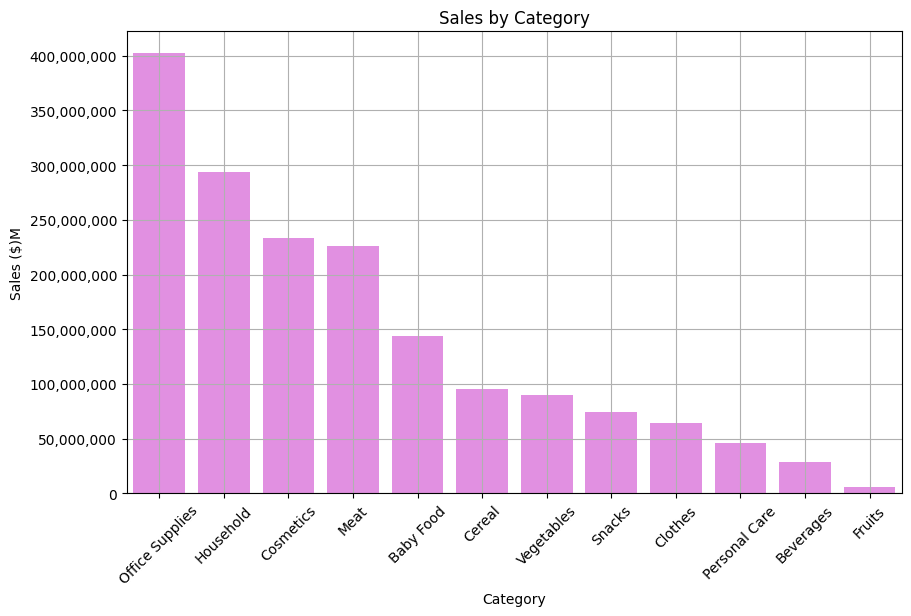

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = category_sales,  x = "item_type", y = "sales", color = "violet")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales ($)M")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.show()

Найбільше продажів приносять такі три категорії:

* Office Suppliers
* Household
* Cosmetics

Найменші суми продажів від:

* Fruits
* Beverages
* Personal Care

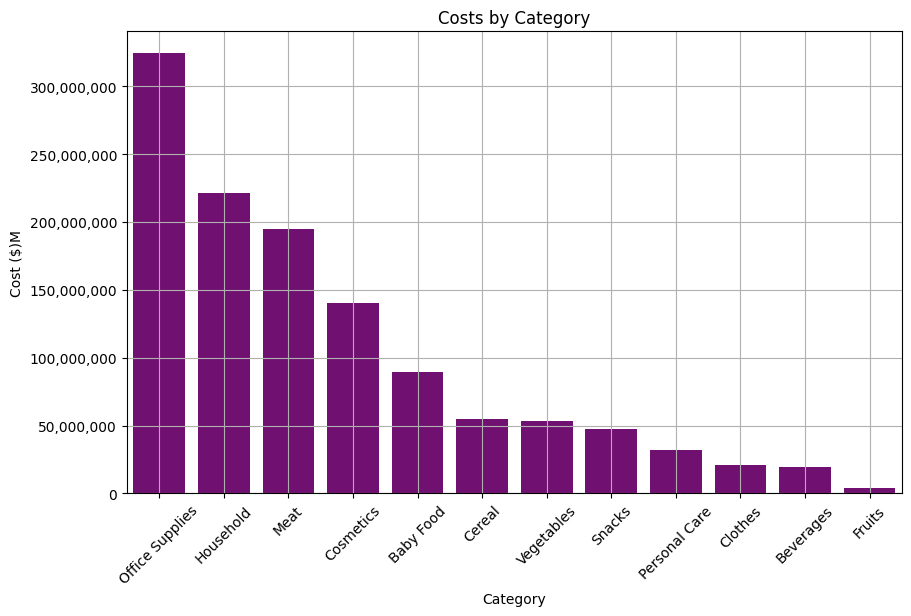

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = category_cost,  x = "item_type", y = "cost", color = "purple")
plt.title("Costs by Category")
plt.xlabel("Category")
plt.ylabel("Cost ($)M")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter (lambda x, p: format(int(x), ",")))
plt.show()

Найбільше витрат у компанії від таких категорій:

* Office Supplies
* Household
* Meat

Найменше витрат від категорій:
* Fruits
* Beverages
* Clothes

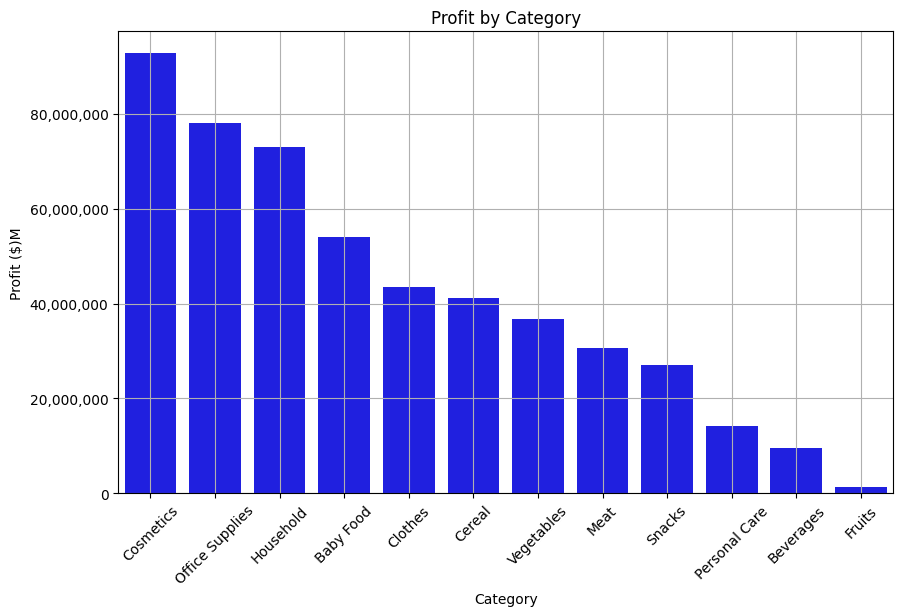

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = category_profit,  x = "item_type", y = "profit", color = "blue")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit ($)M")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.show()

Найбільше прибутку в компанію приносять такі три категорії:


*   Cosmetics
*   Office Suppliers
*   Household

Найменш прибуткові:


*   Fruits
*   Beverages
*   Personal Care




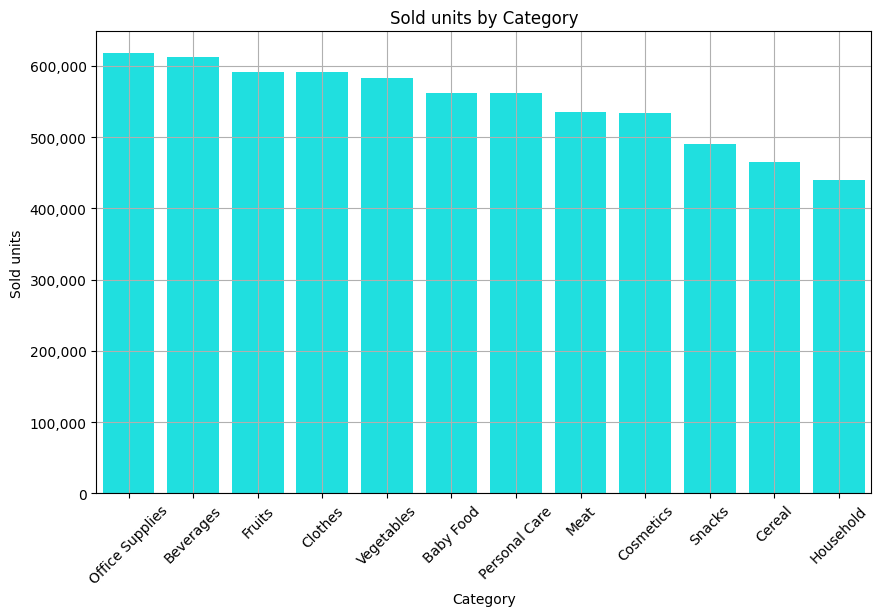

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = category_units,  x = "item_type", y = "units_sold", color = "cyan")
plt.title("Sold units by Category")
plt.xlabel("Category")
plt.ylabel("Sold units")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Найпопулярніші категорії за кількістю проданих товарів:

* Office Supplies
* Beverages
* Fruits

Найменше продано одиниць серед категорій:
* Household
* Cereal
* Snacks

In [ ]:
category_total = df.groupby("item_type")[["profit", "sales", "cost"]].sum().sort_values("profit", ascending = False)

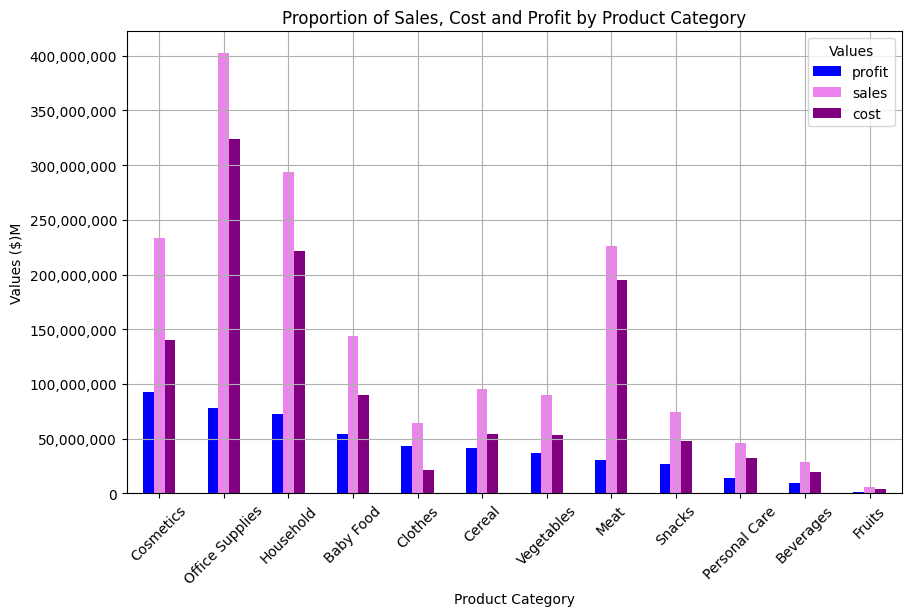

In [ ]:
category_total.plot(
    kind = "bar",
    figsize=(10,6),
    color = ["blue", "violet", "purple"]
)
plt.xlabel("Product Category")
plt.ylabel("Values ($)M")
plt.title("Proportion of Sales, Cost and Profit by Product Category")
plt.legend(title = "Values", loc = "upper right", labels = ["profit", "sales", "cost"])
plt.xticks(rotation = 45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

На цьому графіку видно, що як за кількістю продажів, так і за прибутком топ 3 категорії:
* Cosmetics
* Office Suppliers
* Household

Категорія Meat виділяється тим, що маючи відносно хороші продажі через великі витрати не приносить пропорційного продажам прибутку.
Категорія Clothes - єдина, де прибуток перевищує витрати.

Три категорії, які мають низький відсоток як продажів, так і прибутку:
* Fruits
* Beverages
* Personal Care

In [ ]:
top_country_sales = df.groupby("country")["sales"].sum().nlargest(10).sort_values(ascending = False).reset_index()
top_country_profit = df.groupby("country")["profit"].sum().nlargest(10).sort_values(ascending = False).reset_index()
top_country_cost = df.groupby("country")["cost"].sum().nlargest(10).sort_values(ascending = False).reset_index()
top_country_units = df.groupby("country")["units_sold"].sum().nlargest(10).sort_values(ascending = False).reset_index()
region_sales = df.groupby("region")["sales"].sum().nlargest(10).sort_values(ascending = False).reset_index()
region_profit = df.groupby("region")["profit"].sum().nlargest(10).sort_values(ascending = False).reset_index()
region_cost = df.groupby("region")["cost"].sum().nlargest(10).sort_values(ascending = False).reset_index()
region_units = df.groupby("region")["units_sold"].sum().nlargest(10).sort_values(ascending = False).reset_index()

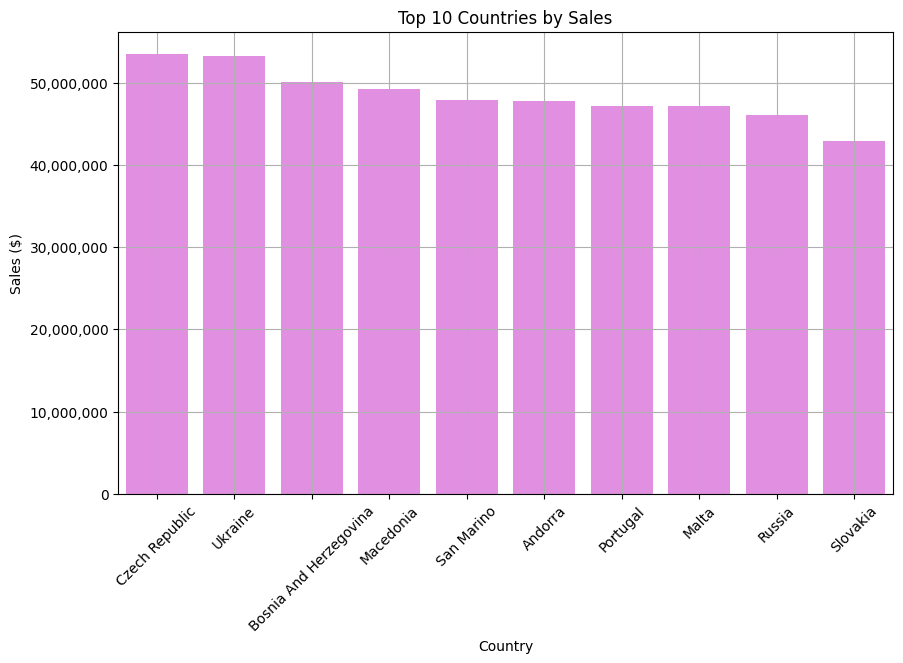

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = top_country_sales,  x = "country", y = "sales", color = "violet")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

На графіку серед 45 країн представлено топ-10 країн, в яких відбулось найбільше продажів. Очолюють цю вибірку Чехія, Україна та Боснія і Герцеговина - сума продажів становить понад 50 000 000 доларів.

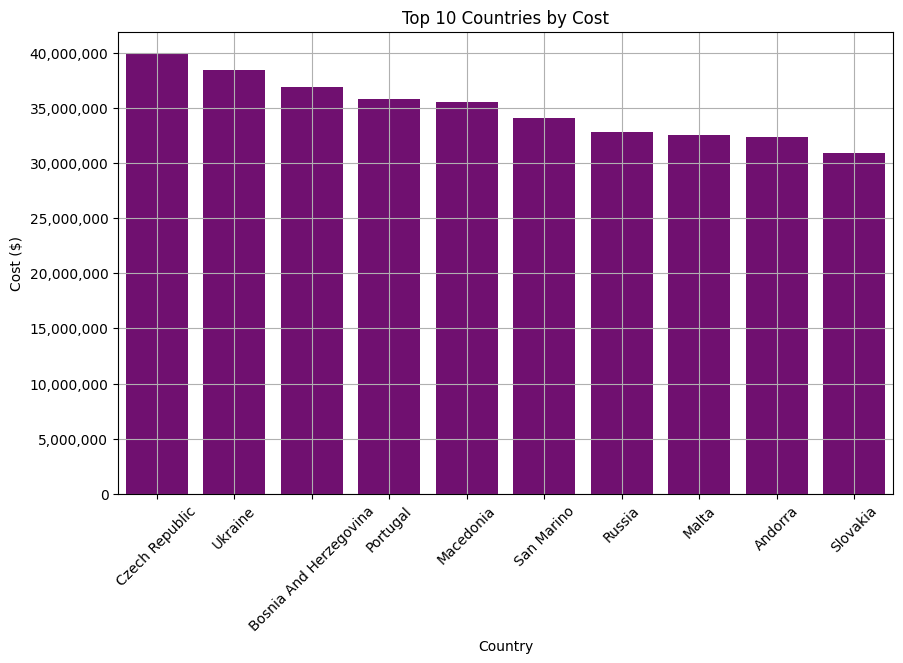

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = top_country_cost,  x = "country", y = "cost", color = "purple")
plt.title("Top 10 Countries by Cost")
plt.xlabel("Country")
plt.ylabel("Cost ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

До вибірки топ-10 країн за сумою витрати потрапили ті самі країни, що й за сумою продажів. Діапазон витрат від 32 до 40 млн.дол.

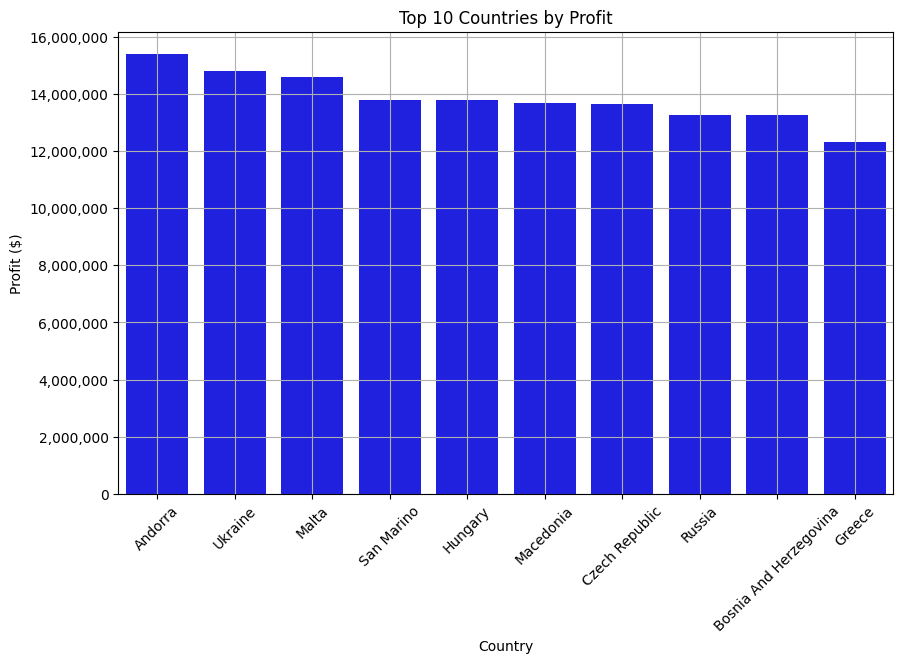

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = top_country_profit,  x = "country", y = "profit", color = "blue")
plt.title("Top 10 Countries by Profit")
plt.xlabel("Country")
plt.ylabel("Profit ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Незважаючи на продажі та витрати на реалізацію продукції, перелік країн змінився. Замість Словаччини і Португалії в цей перелік входять Греція та Угорщина.
Найбільш прибуткова країна - Андорра. Це дуже цікаве спостереження, адже ця країна має населення близько 90 тисяч осіб.

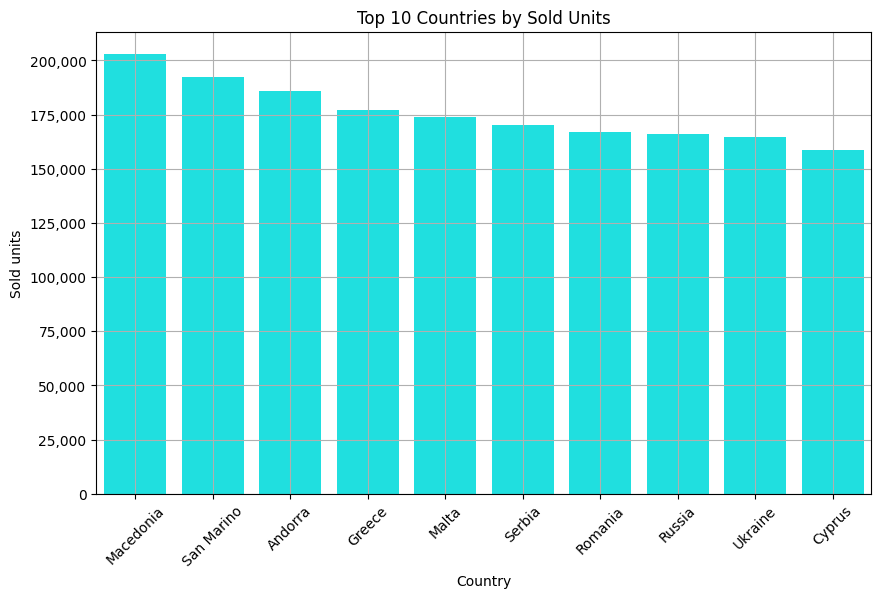

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = top_country_units,  x = "country", y = "units_sold", color = "cyan")
plt.title("Top 10 Countries by Sold Units")
plt.xlabel("Country")
plt.ylabel("Sold units")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

В цій вибірці топ-10 країн з найбільшою кількістю замовлених товарів з'явились Кіпр, Сербія та Румунія. Це означає, що найпопулярніші продукти в цих країнах з категорій, що приносять порівняно меншу суму в чеку та менше чистого прибутку.

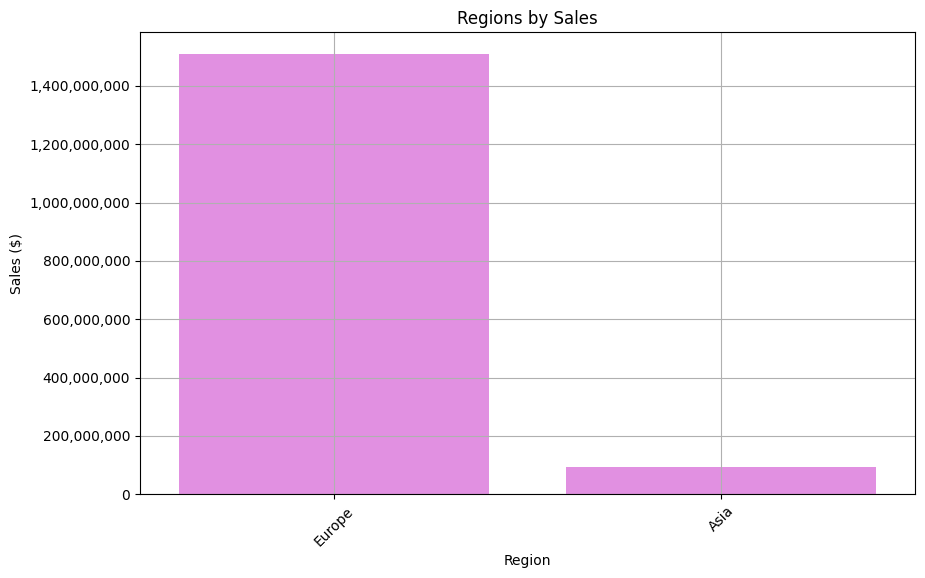

In [ ]:

plt.figure(figsize=(10,6))
sns.barplot(data = region_sales,  x = "region", y = "sales", color = "violet")
plt.title("Regions by Sales")
plt.xlabel("Region")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Основний ринок збуту компанії знаходиться серед країн Європи. Це було помітно, ще на етапі аналізу по країнах. Продажі від країн Європи сягають 1,4 млрд.дол. Від країн Азії близько 100 млн.дол.

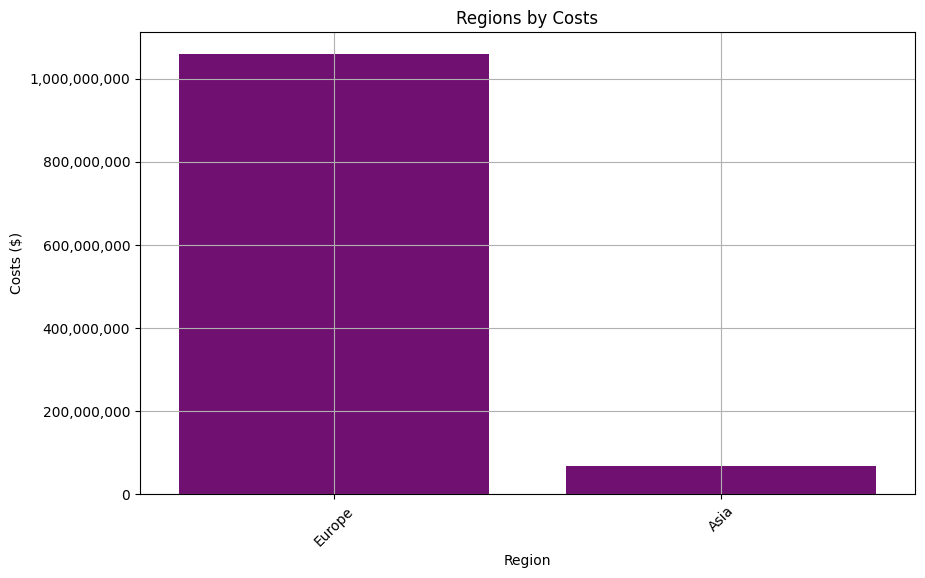

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = region_cost,  x = "region", y = "cost", color = "purple")
plt.title("Regions by Costs")
plt.xlabel("Region")
plt.ylabel("Costs ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Витрати по регіонах пропорційні продажам. В країнах Європи близько 1,2 млрд.дол, в країнах Азії менше 100 млн.

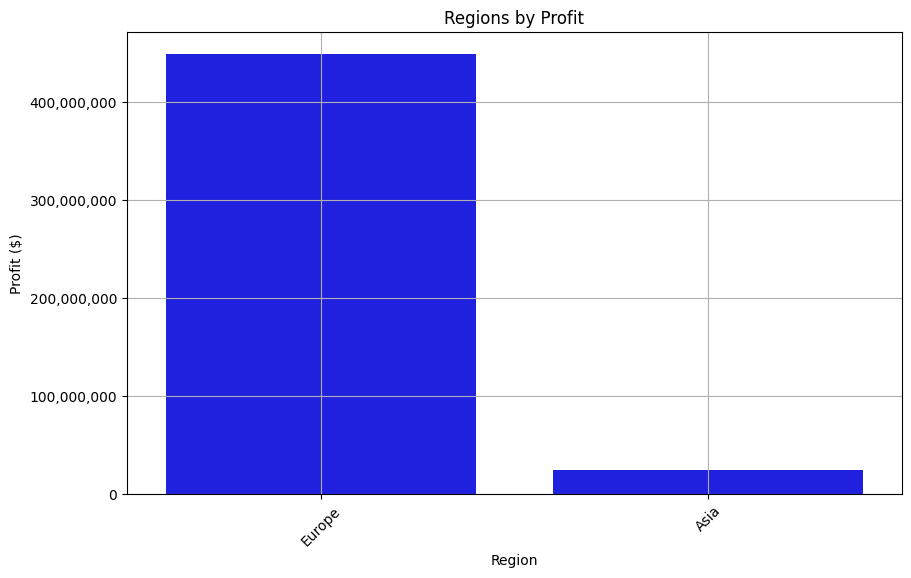

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = region_profit,  x = "region", y = "profit", color = "blue")
plt.title("Regions by Profit")
plt.xlabel("Region")
plt.ylabel("Profit ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Прибуток від країн Європи сягає понад 400 млн.дол., від країн Азії близько 20 млн.дол.

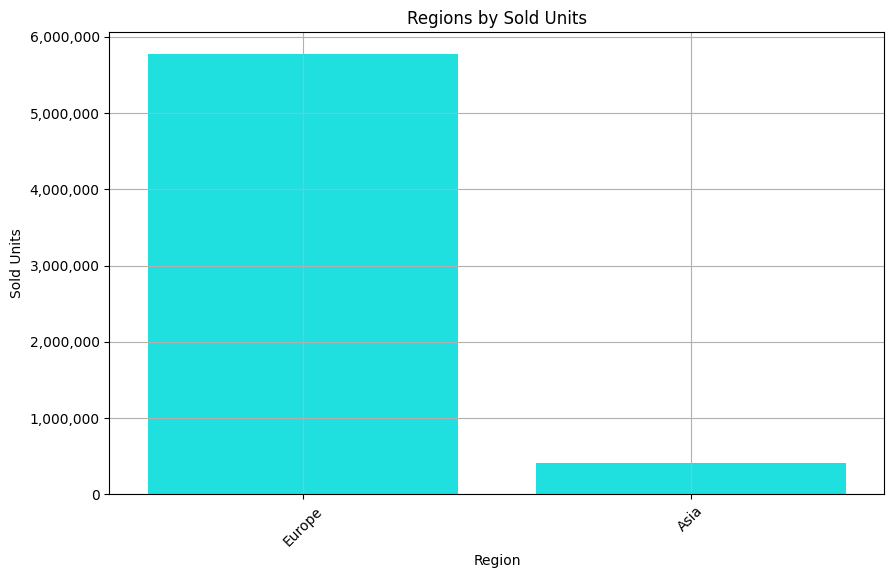

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = region_units,  x = "region", y = "units_sold", color = "cyan")
plt.title("Regions by Sold Units")
plt.xlabel("Region")
plt.ylabel("Sold Units")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Тут теж основна маса проданих товарів від країн Європи - близько 5,8 млн.

In [ ]:
region_total = df.groupby("region")[["profit", "sales", "cost"]].sum().sort_values("sales", ascending = False)

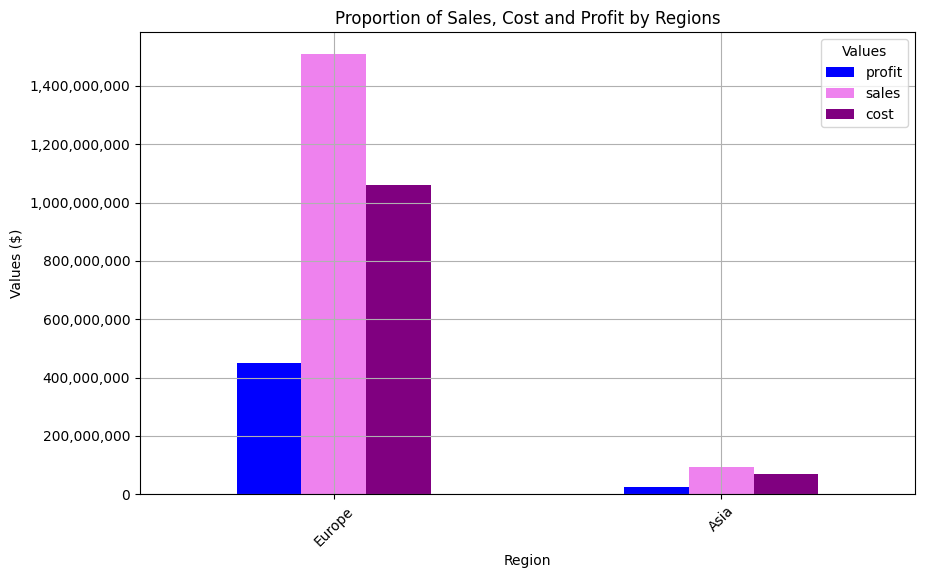

In [ ]:
region_total.plot(
    kind = "bar",
    figsize=(10,6),
    color = ["blue", "violet", "purple"]
)
plt.xlabel("Region")
plt.ylabel("Values ($)")
plt.title("Proportion of Sales, Cost and Profit by Regions")
plt.legend(title = "Values", loc = "upper right", labels = ["profit", "sales", "cost"])
plt.xticks(rotation = 45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Цей графік відображає продажі, витрати та прибутки в Європі та Азії. Перевага європейського ринку очевидна.

In [ ]:
sub_region_sales = df.groupby("sub-region")["sales"].sum().sort_values(ascending = False).reset_index()
sub_region_profit = df.groupby("sub-region")["profit"].sum().sort_values(ascending = False).reset_index()
sub_region_cost = df.groupby("sub-region")["cost"].sum().sort_values(ascending = False).reset_index()
sub_region_units = df.groupby("sub-region")["units_sold"].sum().sort_values(ascending = False).reset_index()

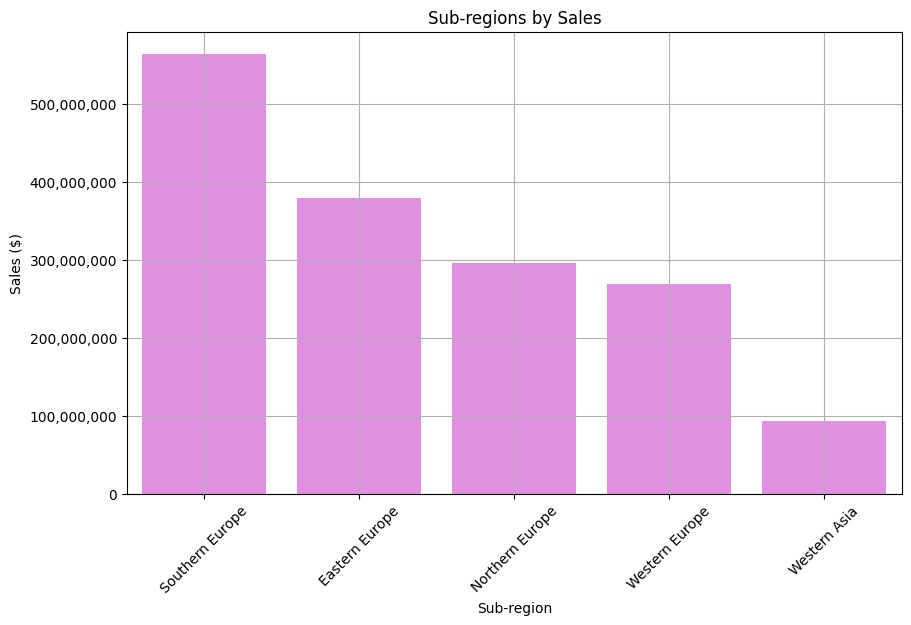

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = sub_region_sales,  x = "sub-region", y = "sales", color = "violet")
plt.title("Sub-regions by Sales")
plt.xlabel("Sub-region")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Тепер можна детальніше розглянути по регіонах частин світу. Низькі показники країн Азії обумовлено тим, що магазин представлений лише серед кількох країн Західної Азії.

Серед країн Європи найбільше продажів було в Південній Європі - понад 500 млн. доларів. Країни з цього регіону ми спостерігали на графіку розподілу серед країн.

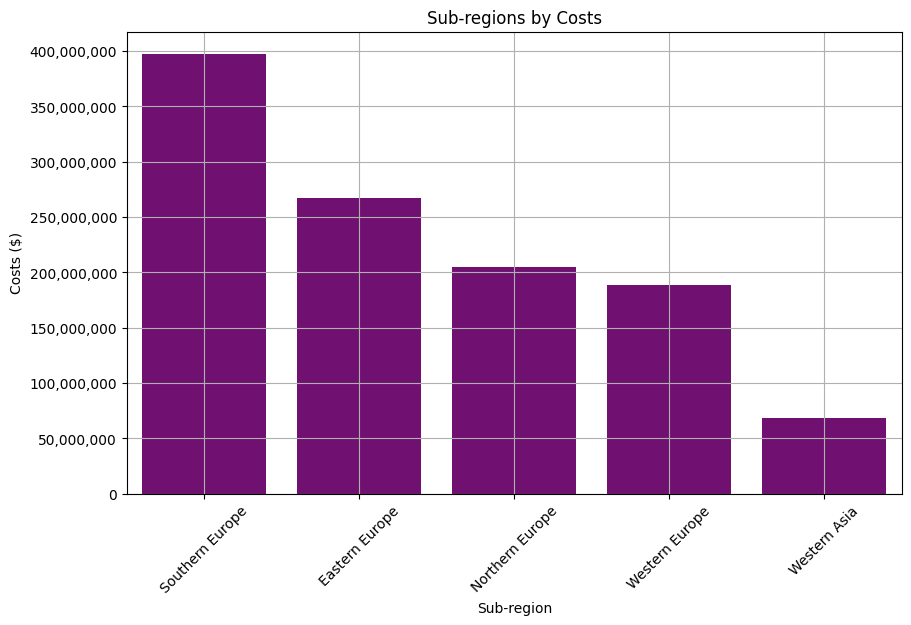

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = sub_region_cost,  x = "sub-region", y = "cost", color = "purple")
plt.title("Sub-regions by Costs")
plt.xlabel("Sub-region")
plt.ylabel("Costs ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Витрати серед країн Південної Європи становлять трохи менше 400 млн. Витрати в країнах Західної Азії становлять близько 70 млн.дол.

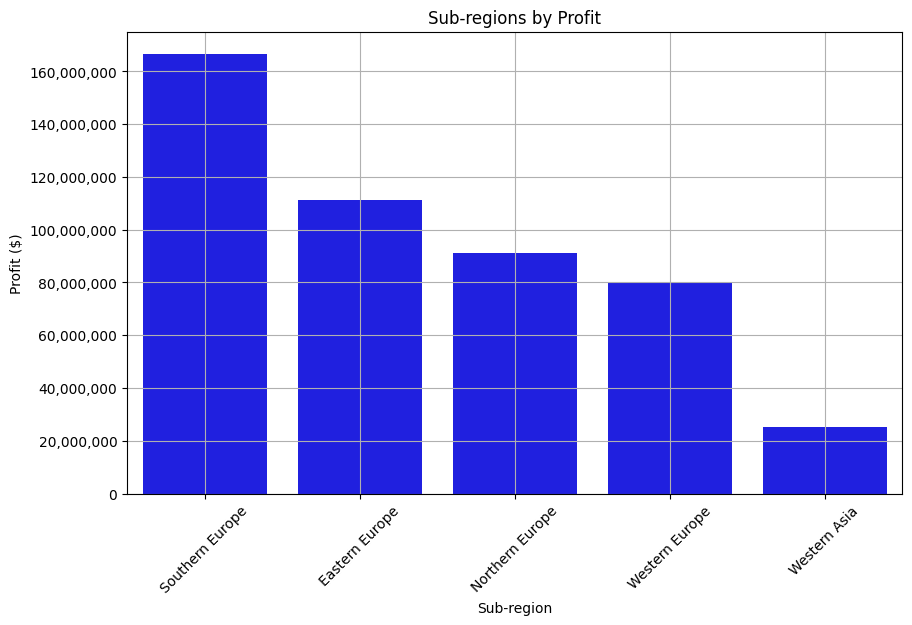

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = sub_region_profit,  x = "sub-region", y = "profit", color = "blue")
plt.title("Sub-regions by Profit")
plt.xlabel("Sub-region")
plt.ylabel("Profit ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Зберігається та сама тенденція по регіонах частин світу. Найбільше прибутку приніс регіон Південної Європи - більше 160 млн.доларів. Східна Європа принесла близько 110 млн.доларів, Північна Європа - 90 млн.дол. прибутку, Західна Європа - 80 млн. доларів. Західна Азія принесла найменше прибутку - близько 20 млн.доларів.

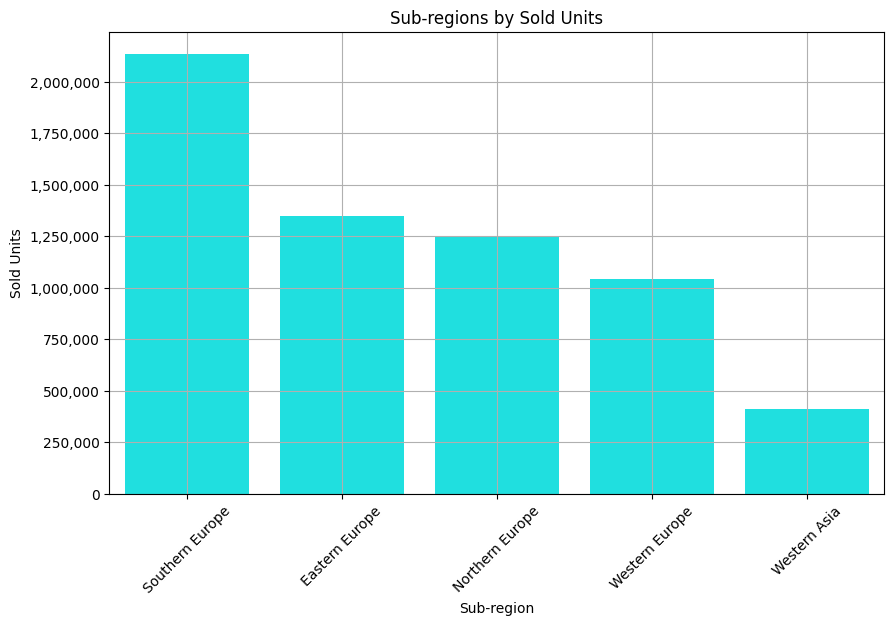

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = sub_region_units,  x = "sub-region", y = "units_sold", color = "cyan")
plt.title("Sub-regions by Sold Units")
plt.xlabel("Sub-region")
plt.ylabel("Sold Units")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Найбільше проданих товарів також серед країн Південної Європи. Найменше - серед країн Західної Азії.

In [ ]:
sub_region_total = df.groupby("sub-region")[["profit", "sales", "cost"]].sum().sort_values("sales", ascending = False)

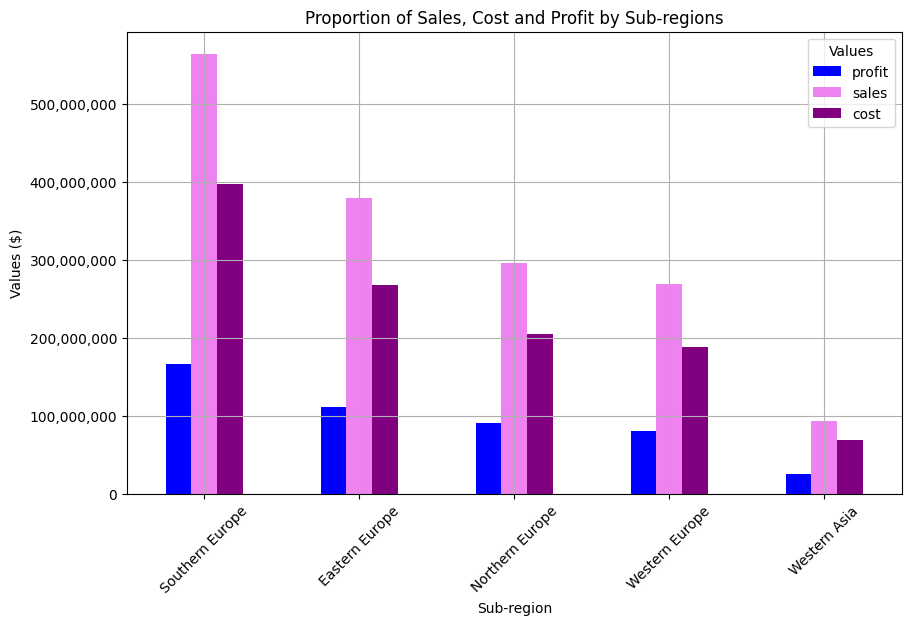

In [ ]:
sub_region_total.plot(
    kind = "bar",
    figsize=(10,6),
    color = ["blue", "violet", "purple"]
)
plt.xlabel("Sub-region")
plt.ylabel("Values ($)")
plt.title("Proportion of Sales, Cost and Profit by Sub-regions")
plt.legend(title = "Values", loc = "upper right", labels = ["profit", "sales", "cost"])
plt.xticks(rotation = 45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

На цьому графіку помітно взаємозв'язок продажів, витрат та прибутку по регіонах частин світу. Всі значення рівномірно розподілені у порядку спадання. Аномалій чи непропорційних співвідношень, які могли б привернути увагу, немає.

In [ ]:
sales_channel = df.groupby("sales_channel")[["sales", "profit", "cost"]].sum()

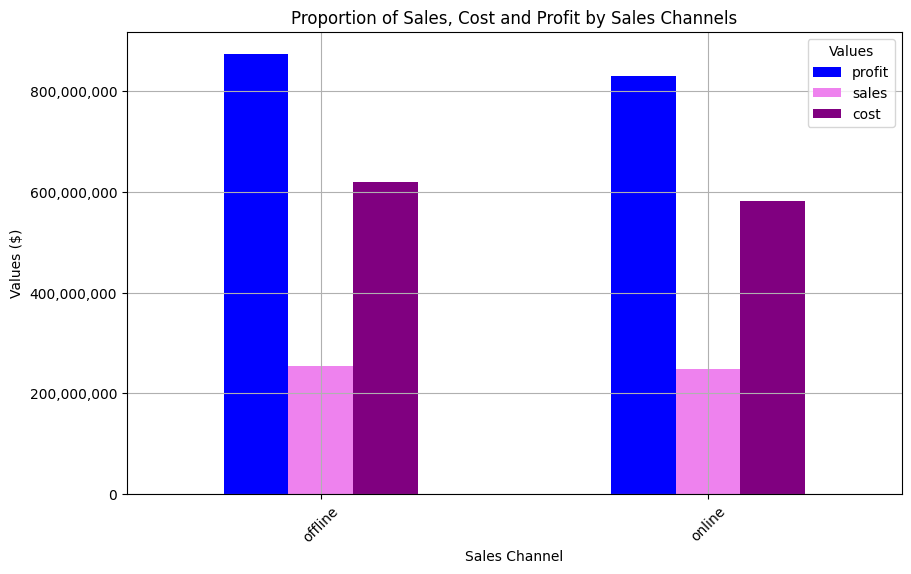

In [ ]:
sales_channel.plot(
    kind = "bar",
    figsize=(10,6),
    color = ["blue","violet", "purple"]
)
plt.xlabel("Sales Channel")
plt.ylabel("Values ($)")
plt.title("Proportion of Sales, Cost and Profit by Sales Channels")
plt.legend(title = "Values", loc = "upper right", labels = ["profit", "sales", "cost"])
plt.xticks(rotation = 45)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Сума продажів рівномірно розподілена між каналами, становить орієнтовно 250 млн.доларів. В офлайн-продажів є мінімальна перевага. Проте витрати на офлайн-продажі більші, ніж онлайн. Різниця між ними орієнтовно 30 млн.доларів.

Прибуток в категорії офлайн-продажів теж переважає над прибутком в категорії онлайн-продажів.

In [ ]:
sales_channel_units = df.groupby("sales_channel")["units_sold"].sum().sort_values(ascending = False).reset_index()

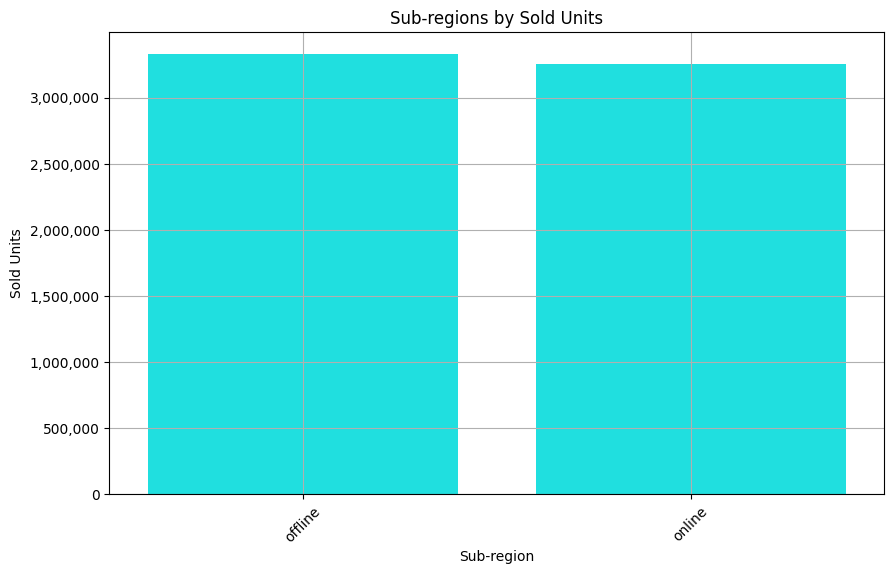

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = sales_channel_units,  x = "sales_channel", y = "units_sold", color = "cyan")
plt.title("Sub-regions by Sold Units")
plt.xlabel("Sub-region")
plt.ylabel("Sold Units")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Кількість проданих товарів рівномірно розподілена через онлайн та офлайн-канали. Офлайн-продажі мають перевагу, але різниця мінімальна.

In [ ]:
df["delivery_days"] = (df["ship_date"]-df["order_date"]).dt.days
print(delivery_days)

0      10 days
1       0 days
2      24 days
3      31 days
4      38 days
         ...  
1325    3 days
1326   28 days
1327    2 days
1328   18 days
1329   36 days
Length: 1330, dtype: timedelta64[ns]


In [ ]:
ship_days_category = df.groupby("item_type")["delivery_days"].mean().sort_values(ascending = False).reset_index()
ship_days_country = df.groupby("country")["delivery_days"].mean().nsmallest(10).sort_values(ascending = False).reset_index()
ship_days_region = df.groupby("region")["delivery_days"].mean().sort_values(ascending = False).reset_index()
ship_days_sub_region = df.groupby("sub-region")["delivery_days"].mean().sort_values(ascending = False).reset_index()

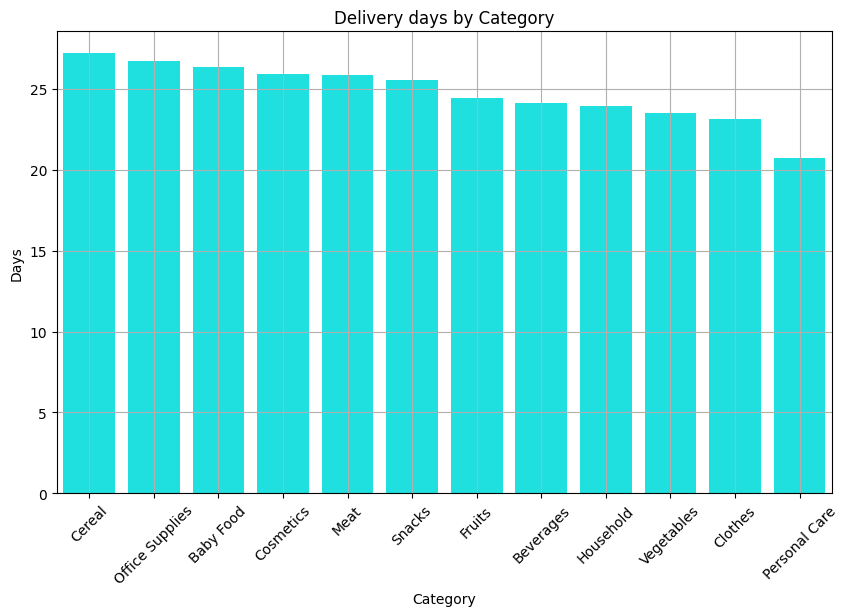

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = ship_days_category,  x = "item_type", y = "delivery_days", color = "cyan")
plt.title("Delivery days by Category")
plt.xlabel("Category")
plt.ylabel("Days")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.show()

На цьому графіку помітно, що найбільша кількість днів потрібна для доставки категорії Cereal - близько 28 днів. Найменше днів потрібно. щоб доставити категорію Personal Care - близько 21 дня.

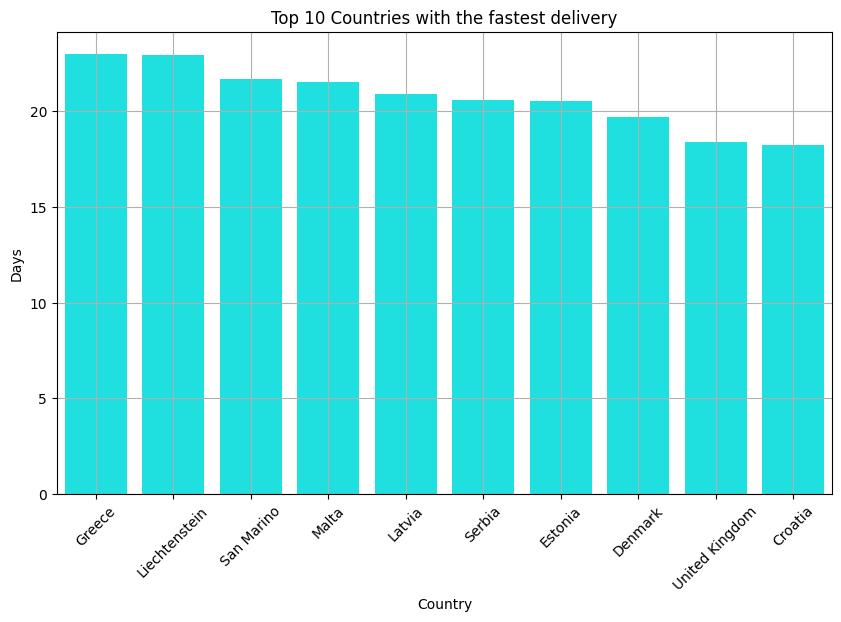

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = ship_days_country,  x = "country", y = "delivery_days", color = "cyan")
plt.title("Top 10 Countries with the fastest delivery")
plt.xlabel("Country")
plt.ylabel("Days")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.show()

На цьому графіку показано топ-10 країн із найшвидшою доставкою, діапазон представлений від 18 до 23 днів. Найшвидше доставляють у Хорватію та Велику Британію - близько 18 днів.

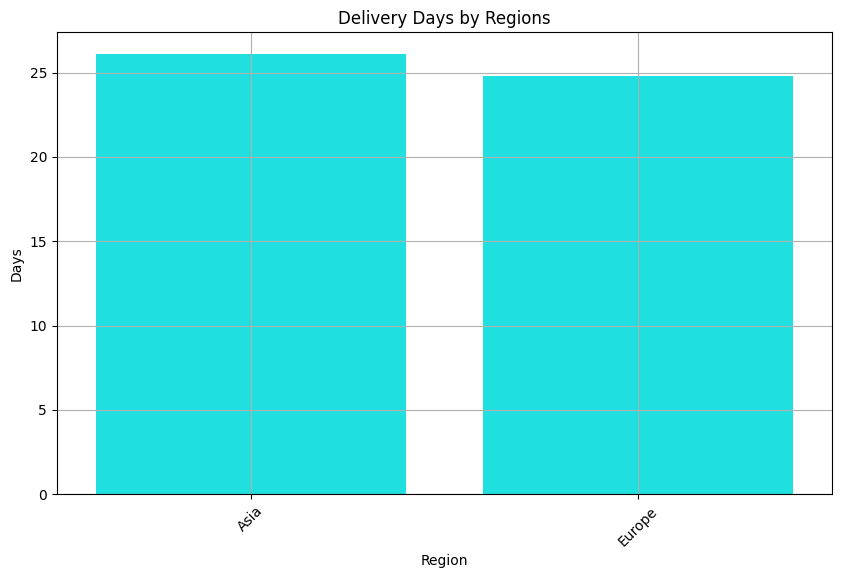

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = ship_days_region,  x = "region", y = "delivery_days", color = "cyan")
plt.title("Delivery Days by Regions")
plt.xlabel("Region")
plt.ylabel("Days")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.show()

Якщо порівняти країни Європи та Азії по кількості днів, що були витрачені на доставку, то помітно, що різниця мінімальна і становить близько 25 днів.

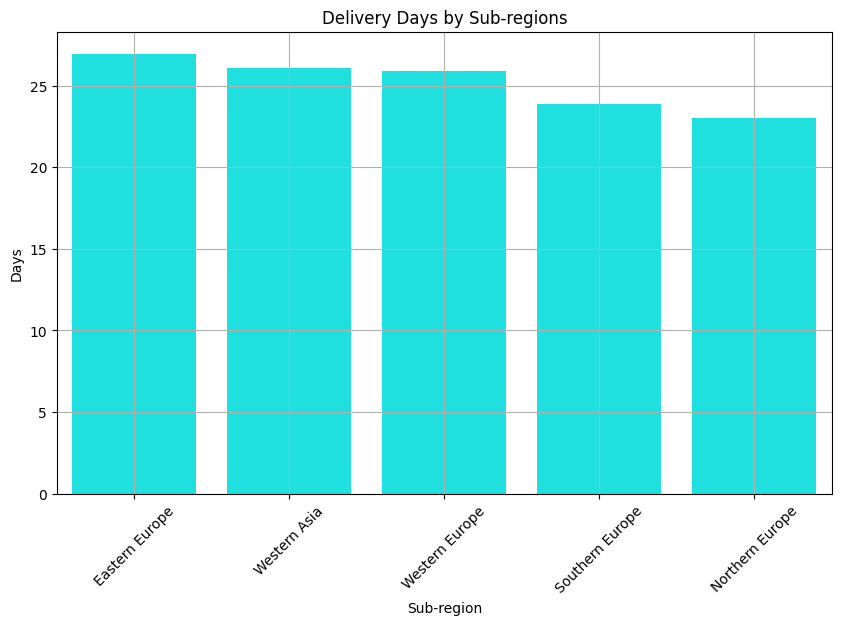

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data = ship_days_sub_region,  x = "sub-region", y = "delivery_days", color = "cyan")
plt.title("Delivery Days by Sub-regions")
plt.xlabel("Sub-region")
plt.ylabel("Days")
plt.ticklabel_format(style="plain", axis="y")
plt.xticks (rotation = 45)
plt.tight_layout
plt.grid(True)
plt.show()

Якщо порівняти регіони частин світу по кількості днів, що були витрачені на доставку - помітно, що різниця між регіонами становить кілька днів. Товари в Північну Європу доставляються найшвидше - 23 дні. Найдовше в Східну Європу - 27 днів.

<Figure size 1200x800 with 0 Axes>

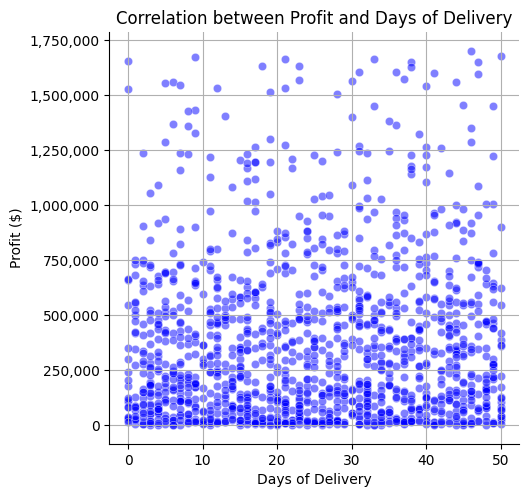

In [ ]:
plt.figure(figsize = (12,8))
sns.relplot(data =df, y = "profit", x = "delivery_days", alpha = 0.5, color = "blue")
plt.title("Correlation between Profit and Days of Delivery")
plt.xlabel("Days of Delivery")
plt.ylabel("Profit ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

In [ ]:
profit_by_days = df.groupby(["delivery_days", "item_type"])["profit"].mean().reset_index()

<Figure size 800x1200 with 0 Axes>

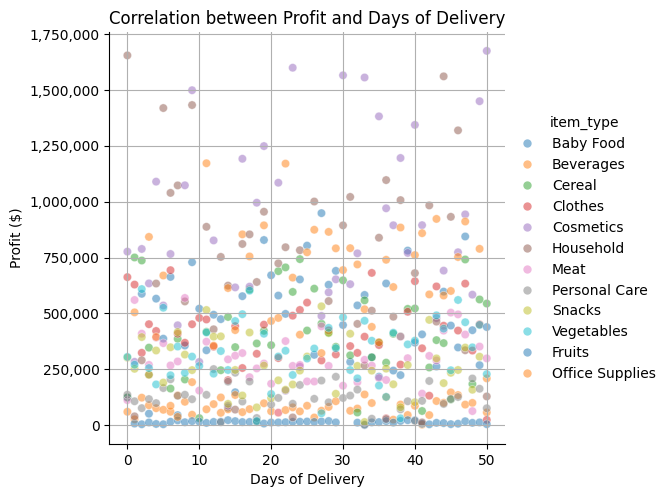

In [ ]:
plt.figure(figsize = (8,12))
sns.relplot(data = profit_by_days, y = "profit", x = "delivery_days", alpha = 0.5, palette = "tab10", hue = "item_type")
plt.title("Correlation between Profit and Days of Delivery")
plt.xlabel("Days of Delivery")
plt.ylabel("Profit ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Цей графік показує взаємозв'язок між відвантаженням товару та прибутком в межах певної категорії. Жодної закономірності чи кореляції тут не помітно.

In [ ]:
year_category = df.groupby(["item_type", pd.Grouper(key="order_date", freq="YE")])["sales"].sum().reset_index()


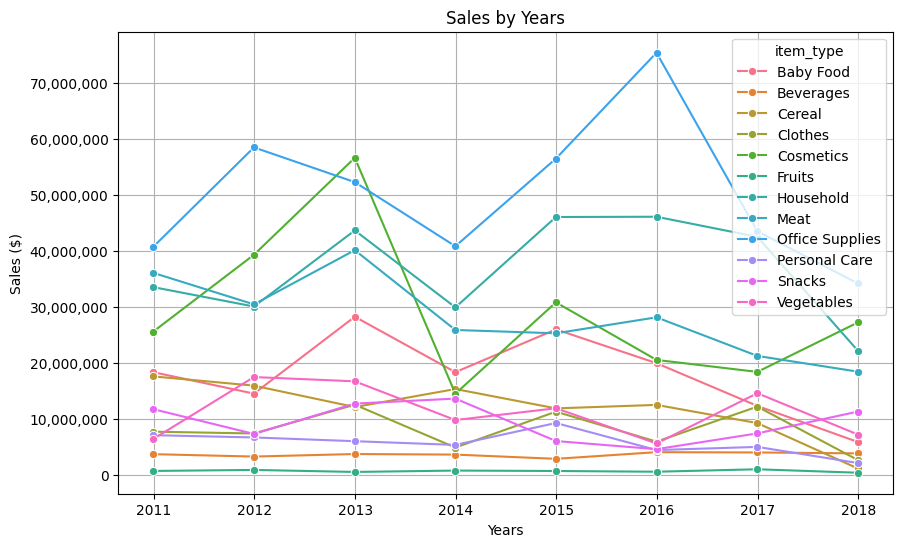

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data = year_category, x = "order_date", y = "sales", hue = "item_type", marker = "o")
plt.title("Sales by Years")
plt.xlabel("Years")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

На графіку показано, що впродовж років продажі за категоріями відбувалися з коливаннями. Помітно, що чим більші суми продажів в певній категорії - тим більші коливання.

Категорія Office Supplies приносила найбільше доходу і має різкі коливання: в 2011 році принесла дохід на суму більше 40 млн.дол.; в 2012 році дохід зріс і майже досяг 60 млн.дол.; в 2014 знову повернувся до рівня 2011 року; в 2016 році досяг пікового значення близько 75 млн.дол. Після цього дохід знову пішов на спад і в 2018 році становив менше доходу за перший рік - близько 35 млн.доларів.

Можна звернути увагу, що в певні роки серед більшості категорій дохід зростав або навпаки падав. У 2014 році продажі знизились серед більш прибуткових категорій. З 2015 позитивний ріст продовжився і в 2017 році продажі серед багатьох категорій пішли на спад.

In [ ]:
df["month"] = df["order_date"].dt.month
monthly_category = df.groupby(["item_type", "month"])["sales"].sum().reset_index()

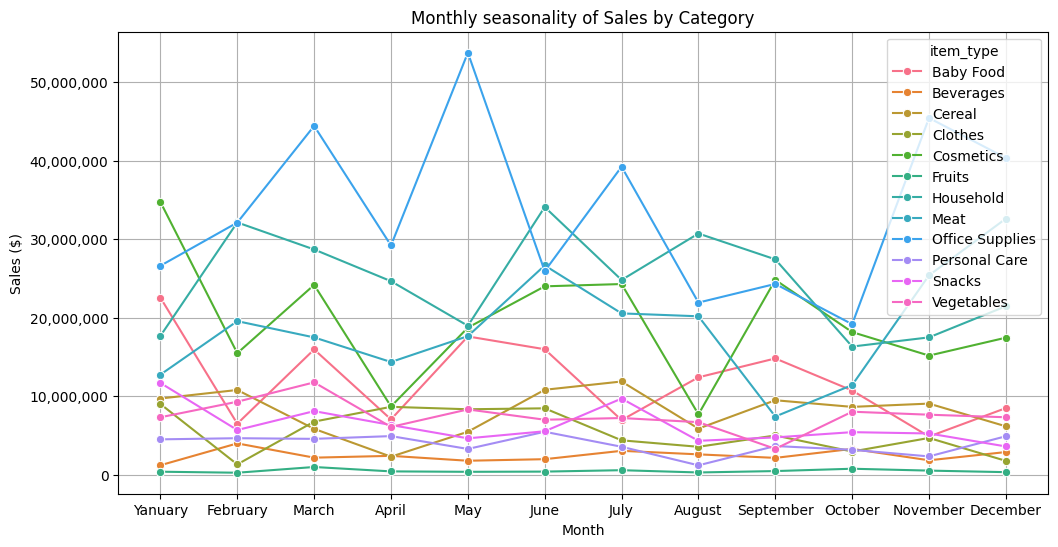

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data = monthly_category, x = "month", y = "sales", hue = "item_type", marker = "o")
plt.title("Monthly seasonality of Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1,13), ["Yanuary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Найбільше виражена сезонність по місяцях таких категорій з найбільшим доходом:
* Office Supplies
* Meat
* Household
* Cosmetics

В квітні та жовтні в більшості категорій був спад.

In [ ]:
top_countries = df.groupby("country")["sales"].sum().nlargest(10).index
df_top = df[df["country"].isin(top_countries)]
year_country = df_top.groupby(["country", "year"])["sales"].sum().reset_index()
monthly_country = df_top.groupby(["country", "month"])["sales"].sum().reset_index()

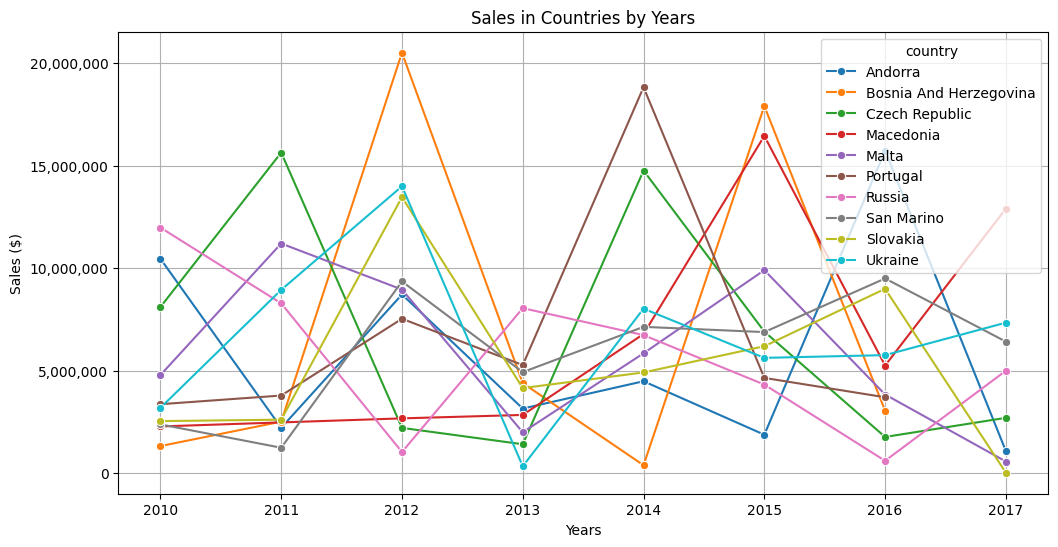

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))
sns.lineplot(data = year_country, x = "year", y = "sales", hue = "country", marker = "o")
plt.title("Sales in Countries by Years")
plt.xlabel("Years")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

На цьому графіку зображена динаміка топ-10 країн за доходом протягом років. Помітно різкі коливання між роками в рамках певної країни, особливо помітно в таких країнах:
* Боснія і Герцеговина
* Португалія
* Андорра

Помітно, що в 2013 році був спад продажів майже в усіх розглянутих країнах. В 2014 та 2015 році продажі зросли, а в певних країнах до пікових значень. Це може означати, що компанія зробила висновки у 2013 році, покращила роботу і посилила свої позиції на ринку в наступні 2 роки. В 2016 році продажі знову почали падати в більшості країн.

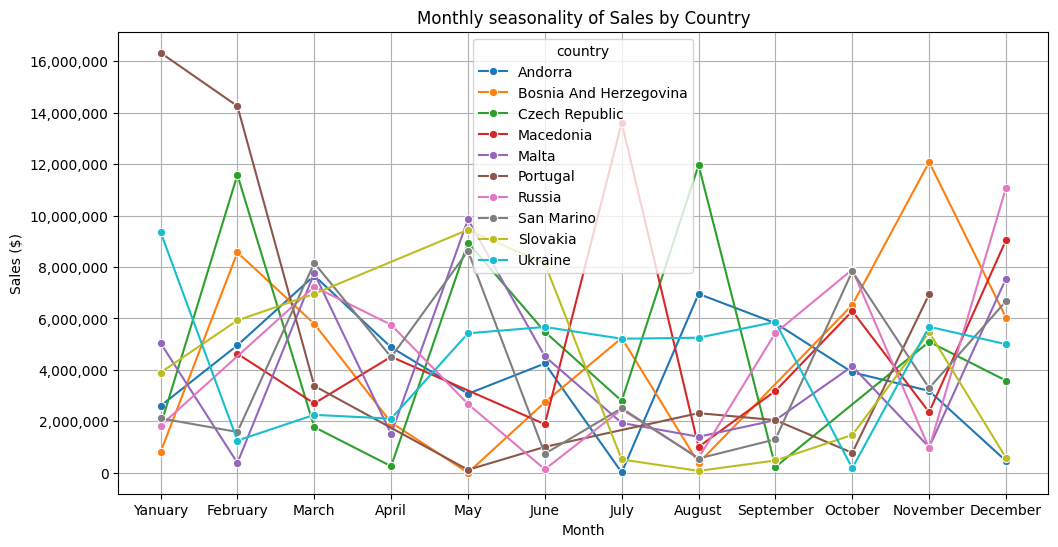

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data = monthly_country, x = "month", y = "sales", hue = "country", marker = "o")
plt.title("Monthly seasonality of Sales by Country")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1,13), ["Yanuary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

В розрізі кожної країни можна спостерігати сезонність по місяцях. Наприклад, в Португалії січень та лютий приносять найбільшу кількість доходу в порівнянні з іншими місяцями.

Помітно, що в квітні в усіх країнах продажі пішли на спад.

In [ ]:
region_year = df.groupby(["year", "region"])["sales"].sum().reset_index()
region_month = df.groupby(["month", "region"])["sales"].sum().reset_index()

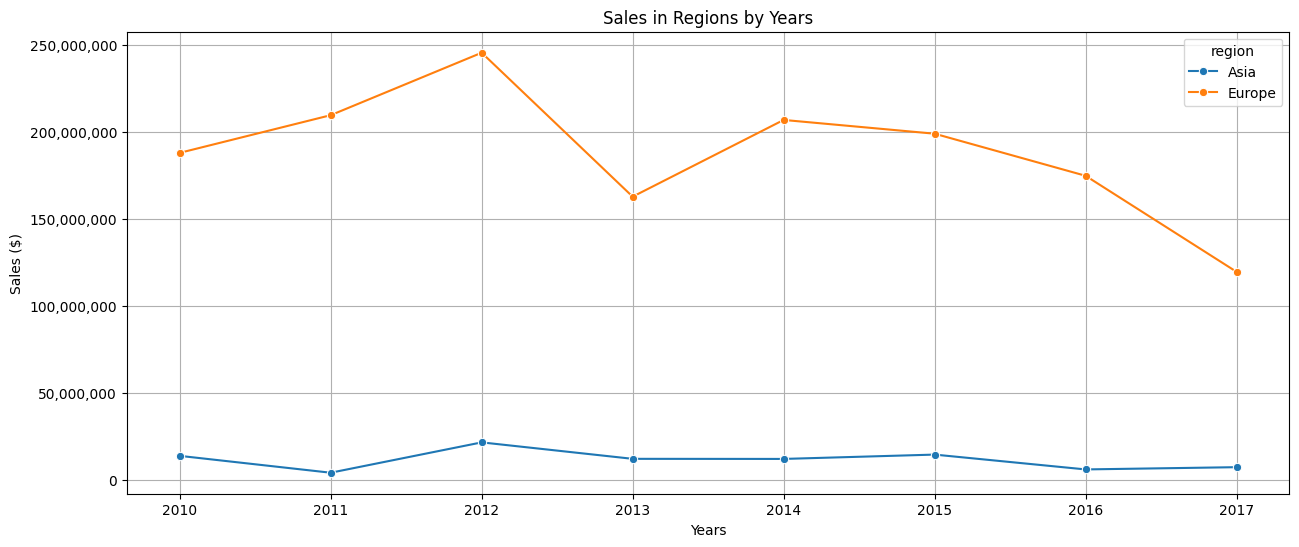

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
sns.lineplot(data = region_year, x = "year", y = "sales", hue = "region", marker = "o")
plt.title("Sales in Regions by Years")
plt.xlabel("Years")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Продажі в Азії впровдовж років відбувались без суттєвих коливань, найбільшого показника досягли в 2012 році.
Серед країн Європи 2012 рік теж був найприбутковішим.

Як було показано на попередніх графіках, 2013 рік приніс менше прибутку, ніж інші роки. 2014 рік приніс більше прибутку, але починаючи з 2015 року продажі серед країн Європи поступово пішли на спад.

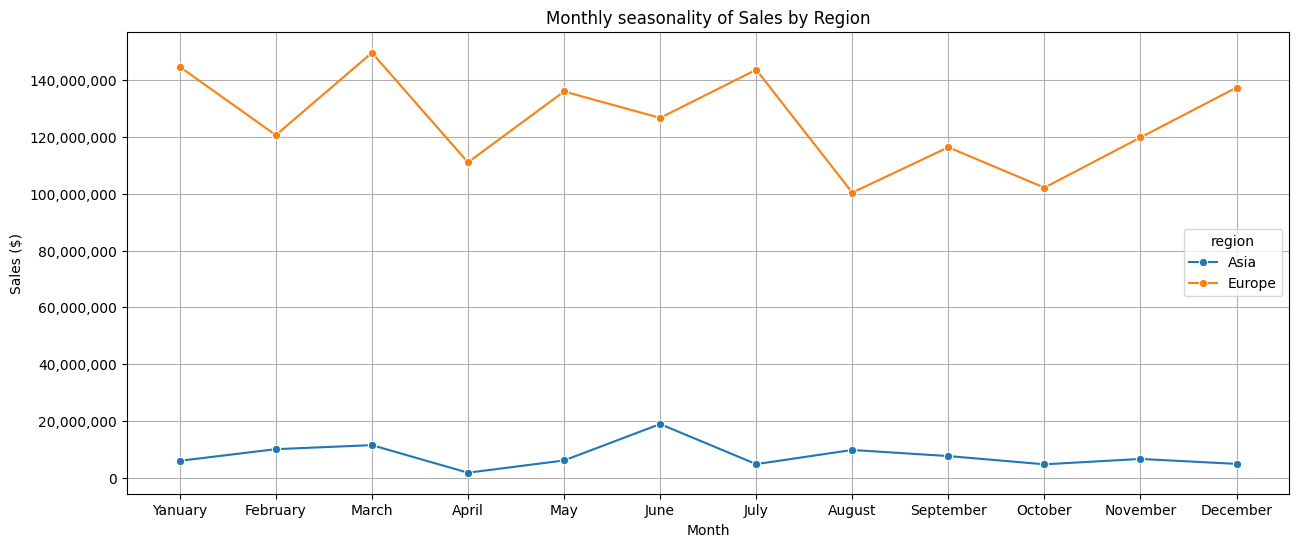

In [ ]:
plt.figure(figsize=(15,6))
sns.lineplot(data = region_month, x = "month", y = "sales", hue = "region", marker = "o")
plt.title("Monthly seasonality of Sales by Region")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(range(1,13), ["Yanuary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Серед країн Азії великих сезонних коливань не спостерігається. Найбільше доходу серед країн Азії в червні - близько 20 млн. дол.

Серед країн Європи продажі коливаються кожного місяця. Найбільше продажів у січні, березні та липні - більше 140 млн. дол. Найменше доходу в серпні та жовтні - близько 100 млн. дол.

In [ ]:
df["day"] = df["order_date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day"] = pd.Categorical(df["day"], categories=day_order, ordered = True)

In [ ]:
daily_sales = df.groupby(["day", "item_type"], observed = True)["sales"].sum().reset_index()

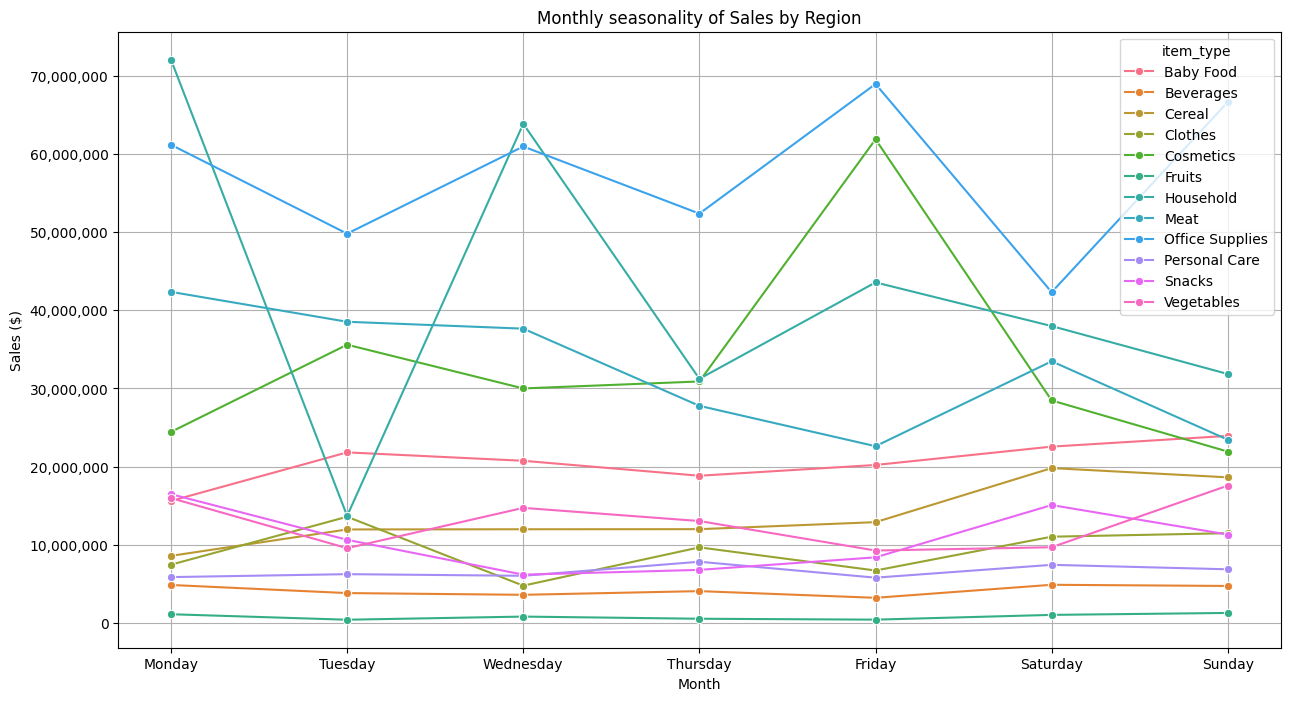

In [ ]:
plt.figure(figsize = (15,8))
sns.lineplot(data = daily_sales, x = "day", y = "sales", hue = "item_type", marker = "o", color = "cyan")
plt.title("Monthly seasonality of Sales by Region")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))
plt.grid(True)
plt.show()

Найбільше день тижня впливає на такі категорії:

* Cosmetics - пік припадає на п'ятницю, спад у неділю та понеділок.
* Office Suplies - найменше продажів у суботу, найбільше - у п'ятницю.
* Household - в розрізі тижня найбільш нестабільні продажі. В понеділок пікове значення, у вівторок має різкий спад.

##Conclusion

Компанії варто спрямувати ресурси на масштабування продажів серед найбільш прибуткових категорій:
* Cosmetics
* Office Supplies
* Household

Можна прибрати категорії Beverages та Fruits і спрямувати ресурси з них на масштабування прибуткових категорій.

Як онлайн, так і офлайн-продажі приносять прибуток. Можна розглянути детальніше витрати на офлайн-продажі, за можливості оптимізувати їх. Щоб прибуток був пропорційний онлайн-продажам.

Оскільки ринок Азії представлений кількома країнами, варто проаналізувати ринок азійських країн. Якщо ситуація з конкуренцією та платоспроможністю населення сприяє - варто масштабуватися.
Те саме стосується країн Європи. Якщо відсоток витрат в певній країні помітно високий - варто проаналізувати, що впливає на більші витрати, чи можна їх зменшити. Якщо це зовнішні чинники (економіка, конкуренти) - варто ресурси перенаправити на більш прибуткову країну або на нові можливості.

Сезонність можна використати на свою користь, в моменти спаду приваблювати покупців цікавими пропозиціями.